# Demonstration: Building a VSX–TESS Light Curve Dataset

This notebook demonstrates the core data pipeline used to build a labeled variable-star light curve dataset. The goal is to start with a series of variable stars and their categories from the **AAVSO VSX** catalog, map each VSX source to one or more possible **TESS Input Catalog (TIC)** identifiers, and finally obtain usable TESS light curve data. The notebook uses three representative examples to show why a simple nearest-neighbor TIC match with SPOC-only light curve search is insufficient, and how the pipeline improves coverage by considering multiple TIC candidates, QLP products, and TESSCut fallback extraction.

Representative examples:

| VSX ID | VSX RA (deg) | VSX Dec (deg) | Final recovery path |
|---|---:|---:|---|
| LMC V0827 | 76.02176 | -66.29695 | TESSCut |
| OGLE-GD-CEP-0948 | 206.05846 | -63.67383 | SPOC |
| ZTF J212148.91+495425.9 | 320.45383 | 49.90721 | QLP |


## 1. Imports and example VSX targets


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy import units as u

try:
    from astroquery.mast import Catalogs
    ASTROQUERY_AVAILABLE = True
except Exception as e:
    ASTROQUERY_AVAILABLE = False
    print('astroquery is not available:', e)

try:
    import lightkurve as lk
    LIGHTKURVE_AVAILABLE = True
except Exception as e:
    LIGHTKURVE_AVAILABLE = False
    print('lightkurve is not available:', e)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 120)


In [2]:
vsx_examples = pd.DataFrame([
    {'vsx_id': 'LMC V0827', 'ra_deg': 76.02176, 'dec_deg': -66.29695, 'expected_final_method': 'TESSCut'},
    {'vsx_id': 'OGLE-GD-CEP-0948', 'ra_deg': 206.05846, 'dec_deg': -63.67383, 'expected_final_method': 'SPOC'},
    {'vsx_id': 'ZTF J212148.91+495425.9', 'ra_deg': 320.45383, 'dec_deg': 49.90721, 'expected_final_method': 'QLP'},
])
vsx_examples


,vsx_id,ra_deg,dec_deg,expected_final_method
0,LMC V0827,76.02176,-66.29695,TESSCut
1,OGLE-GD-CEP-0948,206.05846,-63.67383,SPOC
2,ZTF J212148.91+495425.9,320.45383,49.90721,QLP


## 2. Original idea: nearest TIC by RA/Dec

The original mapping idea is straightforward: use the VSX sky position, query the TESS Input Catalog nearby, compute the angular separation between the VSX coordinate and each TIC source, and choose the closest TIC ID. This is a reasonable first attempt because both catalogs contain sky positions. However, it is not enough by itself because the nearest TIC source may not have a precomputed SPOC light curve, and a single nearest match may not recover all usable data.

In [3]:
def query_tic_candidates(ra_deg, dec_deg, radius_arcsec=10.0, max_candidates=5):
    """Query TIC candidates near a VSX coordinate and return them sorted by angular distance."""
    if not ASTROQUERY_AVAILABLE:
        raise RuntimeError('astroquery is not available in this environment.')
    vsx_coord = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame='icrs')
    tic_table = Catalogs.query_region(vsx_coord, radius=radius_arcsec * u.arcsec, catalog='TIC')
    rows = []
    for row in tic_table:
        if 'ra' not in row.colnames or 'dec' not in row.colnames or 'ID' not in row.colnames:
            continue
        tic_ra = float(row['ra'])
        tic_dec = float(row['dec'])
        tic_coord = SkyCoord(ra=tic_ra * u.deg, dec=tic_dec * u.deg, frame='icrs')
        sep_arcsec = vsx_coord.separation(tic_coord).arcsec
        tmag = np.nan
        if 'Tmag' in row.colnames:
            try:
                tmag = float(row['Tmag'])
            except Exception:
                tmag = np.nan
        rows.append({'tic_id': str(row['ID']), 'tic_ra_deg': tic_ra, 'tic_dec_deg': tic_dec, 'tic_tmag': tmag, 'sep_arcsec': float(sep_arcsec)})
    df = pd.DataFrame(rows)
    if len(df) == 0:
        return df
    return df.sort_values('sep_arcsec').head(max_candidates).reset_index(drop=True)


### Query nearest TIC candidates

Run this cell to query TIC candidates live through MAST. If the query fails because of network/API issues, the rest of the notebook still uses the known TIC examples.

In [4]:
candidate_tables = {}
for _, star in vsx_examples.iterrows():
    try:
        cand = query_tic_candidates(star['ra_deg'], star['dec_deg'], radius_arcsec=10.0, max_candidates=5)
        candidate_tables[star['vsx_id']] = cand
        print('\n' + '='*80)
        print(star['vsx_id'])
        display(cand)
    except Exception as e:
        print(f'Could not query TIC candidates for {star["vsx_id"]}: {e}')



LMC V0827


,tic_id,tic_ra_deg,tic_dec_deg,tic_tmag,sep_arcsec
0,30855441,76.021760,-66.296952,15.4546,0.008897
1,683451050,76.023475,-66.297907,18.9523,4.244537
2,683724349,76.019141,-66.296200,18.8881,4.653703
3,683724347,76.017614,-66.295641,19.6595,7.628325
4,683724346,76.016984,-66.298160,19.8566,8.170504



OGLE-GD-CEP-0948


,tic_id,tic_ra_deg,tic_dec_deg,tic_tmag,sep_arcsec
0,321957546,206.058487,-63.673819,14.8222,0.058597
1,1024599055,206.055758,-63.674656,19.0471,5.238685
2,1024599054,206.060755,-63.675032,19.4638,5.670392
3,321957525,206.060192,-63.675390,14.0628,6.259872
4,1024599065,206.061542,-63.671929,20.1264,8.430062



ZTF J212148.91+495425.9


,tic_id,tic_ra_deg,tic_dec_deg,tic_tmag,sep_arcsec
0,63711350,320.453837,49.907200,13.2980,0.039886
1,2016781083,320.454805,49.907377,18.4814,2.338931
2,2016782508,320.453037,49.907888,14.9541,3.057514
3,2016781082,320.455256,49.907281,17.1558,3.317077
4,2016782501,320.452621,49.906119,19.3314,4.826132


## 3. SPOC-only search: why the original approach is insufficient

After choosing the closest TIC match, the first attempt was to search only for SPOC light curves. SPOC products are high-quality and convenient, but they cover only a subset of TESS targets. The three examples demonstrate the limitation: among these cases, only **OGLE-GD-CEP-0948** has a SPOC light curve.

In [5]:
known_examples = pd.DataFrame([
    {'vsx_id': 'LMC V0827', 'tic_id': '30855441', 'expected_final_method': 'TESSCut'},
    {'vsx_id': 'OGLE-GD-CEP-0948', 'tic_id': '321957546', 'expected_final_method': 'SPOC'},
    {'vsx_id': 'ZTF J212148.91+495425.9', 'tic_id': '63711350', 'expected_final_method': 'QLP'},
])
known_examples


,vsx_id,tic_id,expected_final_method
0,LMC V0827,30855441,TESSCut
1,OGLE-GD-CEP-0948,321957546,SPOC
2,ZTF J212148.91+495425.9,63711350,QLP


In [6]:
def count_lightcurve_products(tic_id, author):
    """Count TESS lightcurve search results for a TIC ID and author using Lightkurve."""
    if not LIGHTKURVE_AVAILABLE:
        return np.nan
    try:
        sr = lk.search_lightcurve(f'TIC {tic_id}', mission='TESS', author=author)
        return len(sr)
    except Exception as e:
        print(f'Warning: search_lightcurve failed for TIC {tic_id}, author={author}: {e}')
        return np.nan

def count_tesscut_products(tic_id):
    """Count TESSCut search results for a TIC ID using Lightkurve."""
    if not LIGHTKURVE_AVAILABLE:
        return np.nan
    try:
        sr = lk.search_tesscut(f'TIC {tic_id}')
        return len(sr)
    except Exception as e:
        print(f'Warning: search_tesscut failed for TIC {tic_id}: {e}')
        return np.nan


In [7]:
spoc_demo = known_examples.copy()
spoc_demo['SPOC_count'] = spoc_demo['tic_id'].apply(lambda x: count_lightcurve_products(x, 'SPOC'))
spoc_demo['SPOC_found'] = spoc_demo['SPOC_count'] > 0
spoc_demo


No data found for target "TIC 30855441".
No data found for target "TIC 63711350".


,vsx_id,tic_id,expected_final_method,SPOC_count,SPOC_found
0,LMC V0827,30855441,TESSCut,0,False
1,OGLE-GD-CEP-0948,321957546,SPOC,1,True
2,ZTF J212148.91+495425.9,63711350,QLP,0,False


**Interpretation:** SPOC-only matching is too restrictive. It recovers high-quality products when available, but it misses valid stars that can be recovered through QLP or TESSCut.

## 4. Improved idea: keep the top 5 TIC candidates and search SPOC → QLP

The next improvement is to keep up to five nearest TIC candidates for each VSX star, rather than committing to only one nearest match. For each star, candidates are evaluated in increasing angular-distance order. For each candidate, the pipeline checks for SPOC first; if SPOC is not available, it checks QLP. This strategy recovers additional light curves. In this demonstration, **ZTF J212148.91+495425.9** is recovered through QLP even though it is not recovered through SPOC.

In [8]:
spoc_qlp_demo = known_examples.copy()
spoc_qlp_demo['SPOC_count'] = spoc_qlp_demo['tic_id'].apply(lambda x: count_lightcurve_products(x, 'SPOC'))
spoc_qlp_demo['QLP_count'] = spoc_qlp_demo['tic_id'].apply(lambda x: count_lightcurve_products(x, 'QLP'))

def select_spoc_or_qlp(row):
    if row['SPOC_count'] > 0:
        return 'SPOC'
    if row['QLP_count'] > 0:
        return 'QLP'
    return None

spoc_qlp_demo['Selected_after_SPOC_QLP'] = spoc_qlp_demo.apply(select_spoc_or_qlp, axis=1)
spoc_qlp_demo


No data found for target "TIC 30855441".
No data found for target "TIC 321957546".


,vsx_id,tic_id,expected_final_method,SPOC_count,QLP_count,Selected_after_SPOC_QLP
0,LMC V0827,30855441,TESSCut,0,0,NaN
1,OGLE-GD-CEP-0948,321957546,SPOC,1,0,SPOC
2,ZTF J212148.91+495425.9,63711350,QLP,0,4,QLP


## 5. Final fallback: TESSCut for targets without SPOC or QLP

If none of the top TIC candidates has a SPOC or QLP product, the pipeline falls back to TESSCut. TESSCut does not provide a precomputed light curve. Instead, it provides access to full-frame image cutouts from which a light curve can be extracted. In this demonstration, **LMC V0827 → TIC 30855441** is not recovered through SPOC or QLP, but it is recoverable using TESSCut.

In [9]:
final_demo = spoc_qlp_demo.copy()
final_demo['TESSCut_count'] = final_demo['tic_id'].apply(count_tesscut_products)

def select_final_method(row):
    if row['SPOC_count'] > 0:
        return 'SPOC'
    if row['QLP_count'] > 0:
        return 'QLP'
    if row['TESSCut_count'] > 0:
        return 'TESSCut'
    return 'Missing'

final_demo['Final_selected_method'] = final_demo.apply(select_final_method, axis=1)
final_demo


,vsx_id,tic_id,expected_final_method,SPOC_count,QLP_count,Selected_after_SPOC_QLP,TESSCut_count,Final_selected_method
0,LMC V0827,30855441,TESSCut,0,0,NaN,45,TESSCut
1,OGLE-GD-CEP-0948,321957546,SPOC,1,0,SPOC,6,SPOC
2,ZTF J212148.91+495425.9,63711350,QLP,0,4,QLP,4,QLP


### Pipeline logic summarized

```text
For each VSX star:
    Use RA/Dec to query nearby TIC sources
    Keep up to 5 nearest TIC candidates by angular distance

    For each TIC candidate:
        If SPOC light curve exists: use SPOC and stop
        Else if QLP light curve exists: use QLP and stop

    If no SPOC/QLP product exists:
        Use TESSCut at the nearest TIC candidate position
        Extract and save a light curve
```


In the following sections (6 - 8), stats/numbers are collected manually from my local massive downloading, not results from the above code

## 6. Overall coverage improvement


In [10]:
overall_provenance = pd.DataFrame([
    {'Provenance': 'TESSCut', 'Count': 5034, 'Percent': 68.30},
    {'Provenance': 'SPOC', 'Count': 467, 'Percent': 6.34},
    {'Provenance': 'QLP', 'Count': 1612, 'Percent': 21.87},
    {'Provenance': 'Missing', 'Count': 257, 'Percent': 3.49},
])
overall_provenance


,Provenance,Count,Percent
0,TESSCut,5034,68.30
1,SPOC,467,6.34
2,QLP,1612,21.87
3,Missing,257,3.49


In [11]:
coverage_stages = pd.DataFrame([
    {'Stage': 'Nearest TIC + SPOC only\n(initial idea)', 'CoveragePercent': 12.0},
    {'Stage': 'Top-5 candidates +\nSPOC/QLP', 'CoveragePercent': 22.5},
    {'Stage': 'Top-5 candidates +\nSPOC/QLP/TESSCut', 'CoveragePercent': 96.51},
])
coverage_stages


,Stage,CoveragePercent
0,Nearest TIC + SPOC only\n(initial idea),12.00
1,Top-5 candidates +\nSPOC/QLP,22.50
2,Top-5 candidates +\nSPOC/QLP/TESSCut,96.51


### Figure 1. Coverage improvement across pipeline stages

**Caption:** Usable TESS light curve coverage improves from approximately 12% under the initial nearest-TIC/SPOC-only strategy to 22.5% after allowing up to five TIC candidates and searching SPOC/QLP products. Adding TESSCut fallback increases final usable coverage to 96.5%, showing that most VSX-matched variable stars require recovery beyond standard SPOC products.

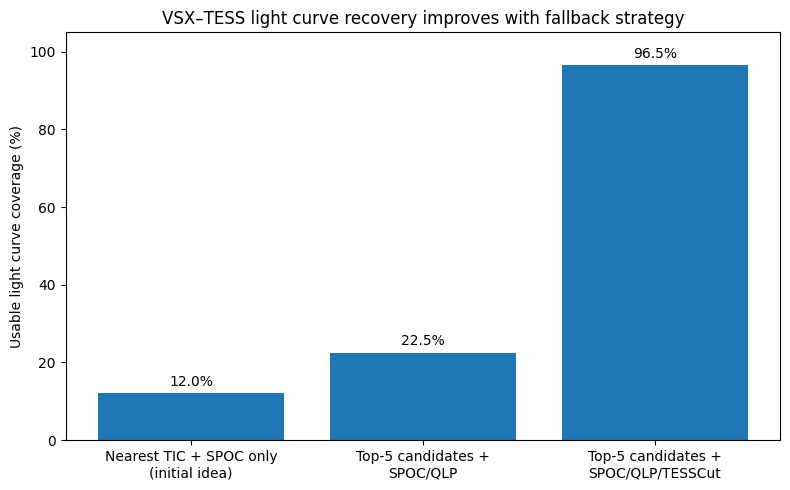

In [12]:
plt.figure(figsize=(8, 5))
bars = plt.bar(coverage_stages['Stage'], coverage_stages['CoveragePercent'])
plt.ylabel('Usable light curve coverage (%)')
plt.ylim(0, 105)
plt.title('VSX–TESS light curve recovery improves with fallback strategy')
for bar, value in zip(bars, coverage_stages['CoveragePercent']):
    plt.text(bar.get_x() + bar.get_width()/2, value + 2, f'{value:.1f}%', ha='center')
plt.tight_layout()
plt.savefig('coverage_improvement_stages.png', dpi=200, bbox_inches='tight')
plt.show()


## 7. Family-level final results


In [13]:
family_stats = pd.DataFrame([
    {'Family': 'CEPHEID', 'TESSCut': 639, 'SPOC': 29, 'QLP': 168, 'Missing': 0, 'Total': 836},
    {'Family': 'CV', 'TESSCut': 525, 'SPOC': 66, 'QLP': 4, 'Missing': 0, 'Total': 595},
    {'Family': 'DSCT_SXPHE', 'TESSCut': 766, 'SPOC': 34, 'QLP': 153, 'Missing': 0, 'Total': 953},
    {'Family': 'ECLIPSING', 'TESSCut': 814, 'SPOC': 8, 'QLP': 174, 'Missing': 0, 'Total': 996},
    {'Family': 'ELLIPSOIDAL_ROT', 'TESSCut': 705, 'SPOC': 122, 'QLP': 170, 'Missing': 0, 'Total': 997},
    {'Family': 'LONG_PERIOD', 'TESSCut': 173, 'SPOC': 90, 'QLP': 717, 'Missing': 0, 'Total': 980},
    {'Family': 'RRLYR', 'TESSCut': 934, 'SPOC': 3, 'QLP': 39, 'Missing': 0, 'Total': 976},
    {'Family': 'XRAY', 'TESSCut': 20, 'SPOC': 24, 'QLP': 12, 'Missing': 0, 'Total': 56},
    {'Family': 'YSO', 'TESSCut': 458, 'SPOC': 91, 'QLP': 175, 'Missing': 0, 'Total': 724},
])
for col in ['TESSCut', 'SPOC', 'QLP', 'Missing']:
    family_stats[col + '_pct'] = 100 * family_stats[col] / family_stats['Total']
family_stats


,Family,TESSCut,SPOC,QLP,Missing,Total,TESSCut_pct,SPOC_pct,QLP_pct,Missing_pct
0,CEPHEID,639,29,168,0,836,76.435407,3.468900,20.095694,0.0
1,CV,525,66,4,0,595,88.235294,11.092437,0.672269,0.0
2,DSCT_SXPHE,766,34,153,0,953,80.377754,3.567681,16.054565,0.0
3,ECLIPSING,814,8,174,0,996,81.726908,0.803213,17.469880,0.0
4,ELLIPSOIDAL_ROT,705,122,170,0,997,70.712136,12.236710,17.051153,0.0
5,LONG_PERIOD,173,90,717,0,980,17.653061,9.183673,73.163265,0.0
6,RRLYR,934,3,39,0,976,95.696721,0.307377,3.995902,0.0
7,XRAY,20,24,12,0,56,35.714286,42.857143,21.428571,0.0
8,YSO,458,91,175,0,724,63.259669,12.569061,24.171271,0.0


### Figure 2. Provenance composition by family

**Caption:** Final light curve provenance differs strongly by variable-star family. RR Lyrae, eclipsing, DSCT/SX Phe, and Cepheid examples rely heavily on TESSCut, while long-period variables are primarily recovered through QLP. This indicates that standard pipeline-product availability is not uniform across variable-star classes.

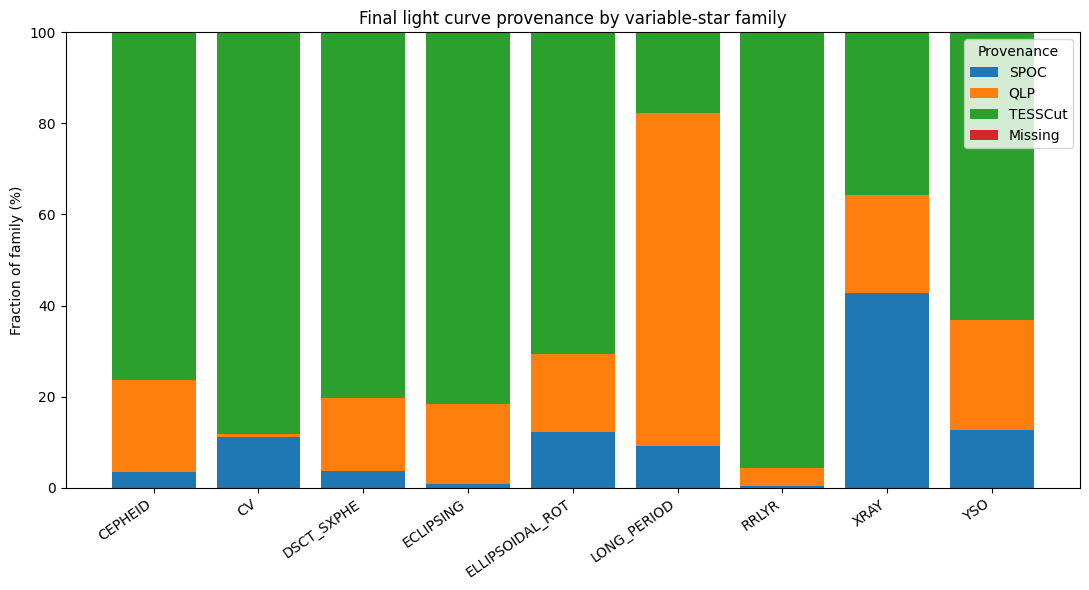

In [14]:
plot_df = family_stats.set_index('Family')[['SPOC_pct', 'QLP_pct', 'TESSCut_pct', 'Missing_pct']]
plt.figure(figsize=(11, 6))
bottom = np.zeros(len(plot_df))
for col in plot_df.columns:
    values = plot_df[col].values
    plt.bar(plot_df.index, values, bottom=bottom, label=col.replace('_pct', ''))
    bottom += values
plt.ylabel('Fraction of family (%)')
plt.title('Final light curve provenance by variable-star family')
plt.xticks(rotation=35, ha='right')
plt.legend(title='Provenance')
plt.tight_layout()
plt.savefig('family_provenance_breakdown.png', dpi=200, bbox_inches='tight')
plt.show()


## 8. Main findings

1. **Nearest TIC + SPOC-only is too incomplete.** It recovers only a small fraction of usable light curves.
2. **Keeping multiple TIC candidates helps.** The top-5 candidate strategy allows additional recovery through QLP.
3. **TESSCut is essential.** The majority of the final dataset, 5,034 out of 7,370 targets, is recovered through TESSCut.
4. **Coverage is class-dependent.** Different variable-star families rely on different recovery paths.
5. **Final coverage is near complete.** The complete pipeline improves usable light curve coverage to 96.5%.

This makes the data pipeline itself a significant methodological component of the project, not merely a preliminary data-download step.